***ANOMALY DETECTION AND TIME SERIES***


---



Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

Answer: Anomaly detection is the process of identifying data points that deviate significantly from expected normal behavior. It is categorized into three main types:
- Point Anomalies: A single data point that stands out as completely abnormal on its own. Example: A one-time 10,000 charge on a credit card that usually only has 20 transactions.
- Contextual Anomalies: A data point that is normal on its own, but abnormal within a specific context. Example: A sudden spike in home heating usage during the middle of July.
- Collective Anomalies: A sequence of individual data points that appear normal by themselves, but indicate an anomaly when grouped together. Example: A script attempting to log in with 500 different incorrect passwords in under 30 seconds.

Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.

Answer:
1. Isolation Forest:
- Isolation Based - Randomly partitions features to isolate points. Anomalies are isolated much faster (fewer splits) than normal points.
- Best Use Case - Large, high-dimensional datasets (e.g., global credit card fraud detection).

2. DBSCAN:
- Density Based - Groups dense clusters together. Anything left outside the dense clusters is flagged as noise/outliers.
- Best Use Case - Low-to-medium dimensions where anomalies are scattered far from tightly grouped data.

3. Local Outlier Factor:
- Local Density Based - Compares a point's local density to its neighbors. Flags points with a much lower density than their surroundings.
- Best Use Case - Datasets with varying densities (e.g., detecting a single faulty sensor in a complex network).

Question 3: What are the key components of a Time Series? Explain each with one example.

Answer: Time Series Analysis Key components:
- Trend: The long-term upward or downward direction of the data over years. Example: A steady increase in global electric vehicle sales over the last decade.
- Seasonality: Predictable patterns that repeat at regular intervals within a year. Example: A massive spike in ice cream sales every summer.
- Cyclicality: Long-term, wave-like fluctuations that repeat over multiple years, often tied to economic cycles without a fixed frequency. Example: The rise and fall of housing market prices over an 8-year economic cycle.
- Noise / Irregularity: Random, unpredictable variations caused by unexpected real-world shocks Example: A sudden drop in a restaurant's daily revenue due to an unexpected severe storm.

Question 4: Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

Answer: A stationary time series is one whose statistical properties—such as mean, variance, and autocorrelation—remain constant over time. It has no predictable trends or seasonal patterns, making it easier to model.

- How To Test for Stationary:
1. Visual Inspection: Plot the data over time to check if the mean (level) or variance (spread) is changing.
2. Statistical Tests: Run the Augmented Dickey-Fuller (ADF) test, if p value is less than equals to 0.05, stationary; else, non stationary.

- How To Tranform Non-Stationary into Stationary
1. Differencing: Subtracting the current value from the previous value ($Y_t - Y_{t-1}$). This removes trends and seasonality.
2. Log Transformation: Applying a logarithm ($\log(Y_t)$) to stabilize a variance that increases or decreases over time.
3. Detrending: Fitting a regression line to the trend and subtracting it from the data to leave only the residuals.



Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.

Answer:
1. AR (Autoregressive):
- Uses past values of the variable itself to predict future values.
- Datasets where the future depends directly on its own recent past (e.g., daily temperature).
2. MA (Moving Averages):
- Uses past forecast errors (shocks/noise) to predict future values.
- Datasets prone to sudden, random shocks that smooth out over time (e.g., immediate stock market shocks).
3. ARIMA:
- Combines AR and MA with I (Integration/Differencing) to handle non-stationary data.
- Non-stationary datasets with a long-term trend but no repeating seasonal patterns.
4. SARIMA:
- Adds seasonal components to ARIMA to handle recurring seasonal cycles.
- Datasets with both a trend and a strong, predictable seasonal pattern (e.g., monthly retail sales, airline passenger counts).
5. SARIMAX:
- Adds exogenous variables (external factors, X) to the SARIMA model.
- Datasets with trends and seasonality that are also heavily influenced by external factors (e.g., predicting electricity demand using weather forecast data).

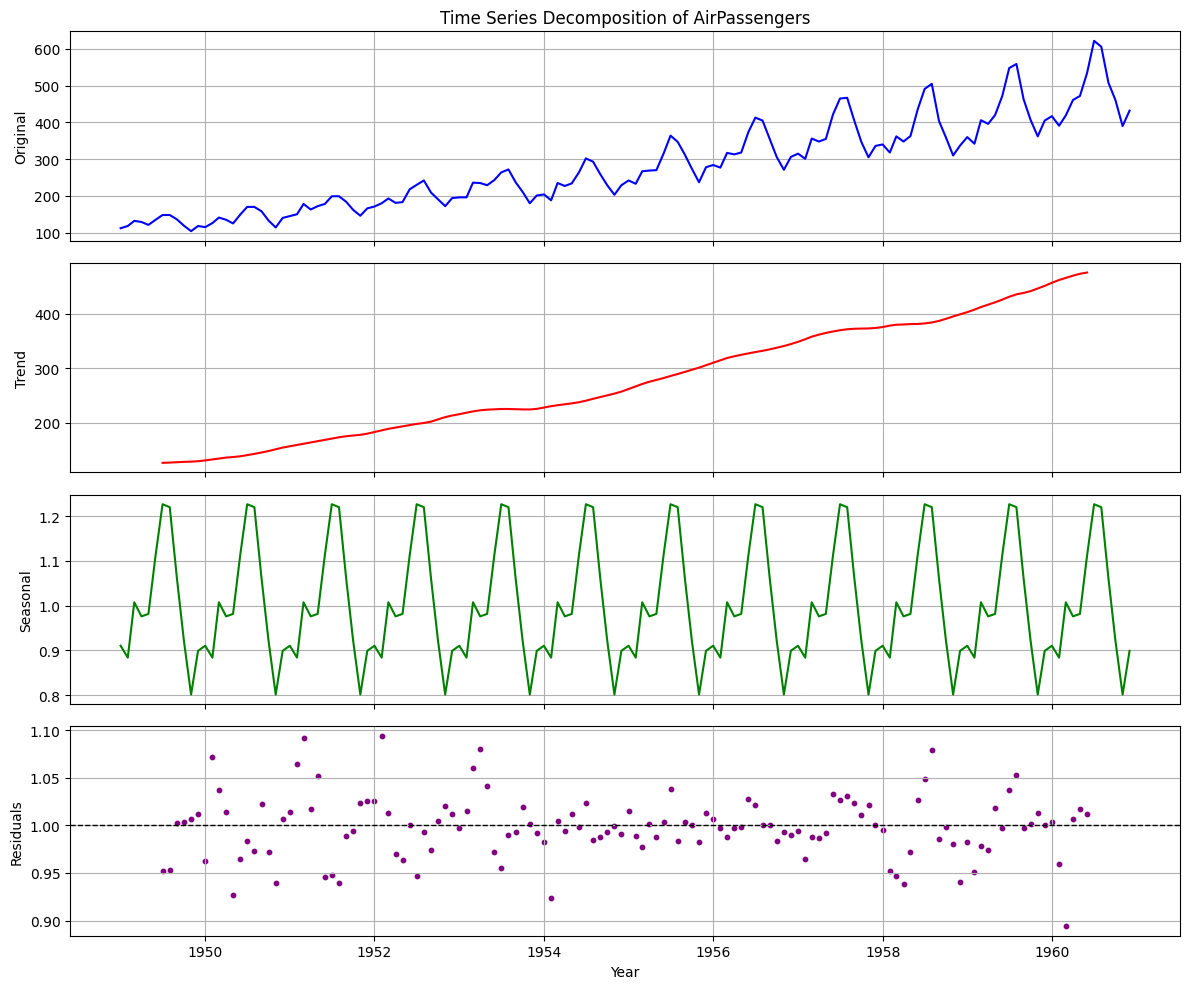

In [1]:
# Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series,
# and decompose it into trend, seasonality, and residual components

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

data = sm.datasets.get_rdataset("AirPassengers", "datasets")
df = data.data

start_date = "1949-01-01"
df.index = pd.date_range(start=start_date, periods=len(df), freq="MS")
df.drop(columns=["time"], inplace=True)
df.columns = ["Passengers"]

decomposition = seasonal_decompose(df["Passengers"], model="multiplicative")

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)


axes[0].plot(df["Passengers"], color="blue", label="Original")
axes[0].set_title("Time Series Decomposition of AirPassengers")
axes[0].set_ylabel("Original")
axes[0].grid(True)

axes[1].plot(decomposition.trend, color="red", label="Trend")
axes[1].set_ylabel("Trend")
axes[1].grid(True)

axes[2].plot(decomposition.seasonal, color="green", label="Seasonal")
axes[2].set_ylabel("Seasonal")
axes[2].grid(True)

axes[3].scatter(
    df.index, decomposition.resid, color="purple", label="Residuals", s=10
)
axes[3].axhline(1, color="black", linestyle="--", linewidth=1)
axes[3].set_ylabel("Residuals")
axes[3].set_xlabel("Year")
axes[3].grid(True)

plt.tight_layout()
plt.show()

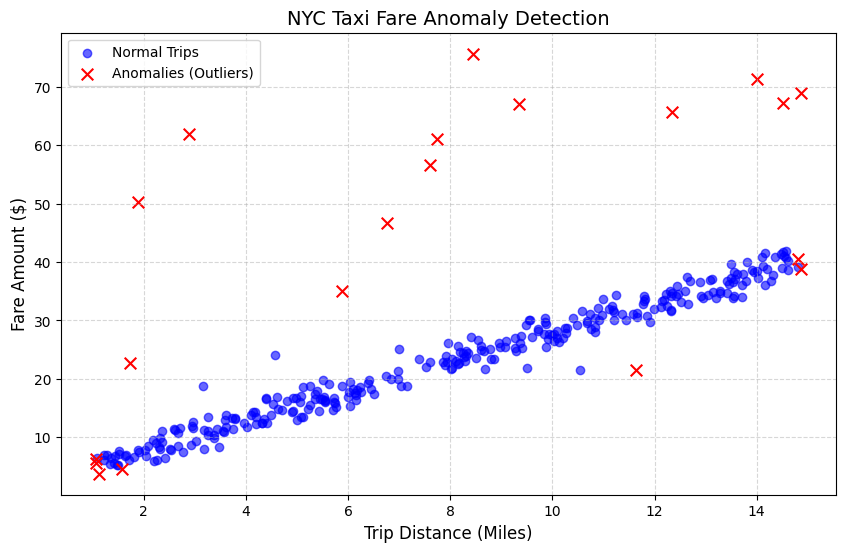

In [2]:
# Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
# detect anomalies. Visualize the anomalies on a 2D scatter plot.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

np.random.seed(42)

normal_distance = np.random.uniform(1, 15, 300)
normal_fare = normal_distance * 2.5 + 3.0 + np.random.normal(0, 1.5, 300)

anomaly_distance = np.random.uniform(1, 15, 20)
anomaly_fare = np.random.uniform(10, 80, 20)

df = pd.DataFrame(
    {
        "Trip_Distance": np.concatenate([normal_distance, anomaly_distance]),
        "Fare_Amount": np.concatenate([normal_fare, anomaly_fare]),
    }
)

model = IsolationForest(contamination=0.06, random_state=42)
model.fit(df[["Trip_Distance", "Fare_Amount"]])

df["Result"] = model.predict(df[["Trip_Distance", "Fare_Amount"]])


plt.figure(figsize=(10, 6))

normal_data = df[df["Result"] == 1]
anomaly_data = df[df["Result"] == -1]

plt.scatter(
    normal_data["Trip_Distance"],
    normal_data["Fare_Amount"],
    color="blue",
    label="Normal Trips",
    alpha=0.6,
)

plt.scatter(
    anomaly_data["Trip_Distance"],
    anomaly_data["Fare_Amount"],
    color="red",
    label="Anomalies (Outliers)",
    marker="x",
    s=70,
)

plt.title("NYC Taxi Fare Anomaly Detection", fontsize=14)
plt.xlabel("Trip Distance (Miles)", fontsize=12)
plt.ylabel("Fare Amount ($)", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

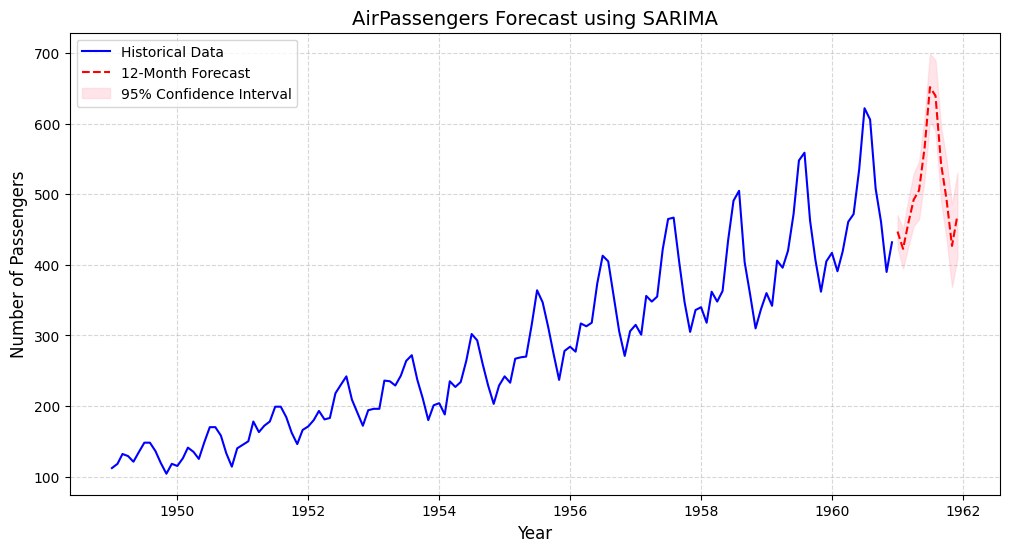

In [3]:
# Question 8: Train a SARIMA model on the monthly airline passengers dataset.
# Forecast the next 12 months and visualize the results.

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

data = sm.datasets.get_rdataset("AirPassengers", "datasets").data
df = pd.DataFrame(data)

df.index = pd.date_range(start="1949-01-01", periods=len(df), freq="MS")
df.drop(columns=["time"], inplace=True)
df.columns = ["Passengers"]

model = sm.tsa.statespace.SARIMAX(
    df["Passengers"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results = model.fit(disp=False)

forecast_steps = 12
forecast = results.get_forecast(steps=forecast_steps)

forecast_mean = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Passengers"], label="Historical Data", color="blue")
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="12-Month Forecast",
    color="red",
    linestyle="--",
)
plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color="pink",
    alpha=0.4,
    label="95% Confidence Interval",
)
plt.title("AirPassengers Forecast using SARIMA", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

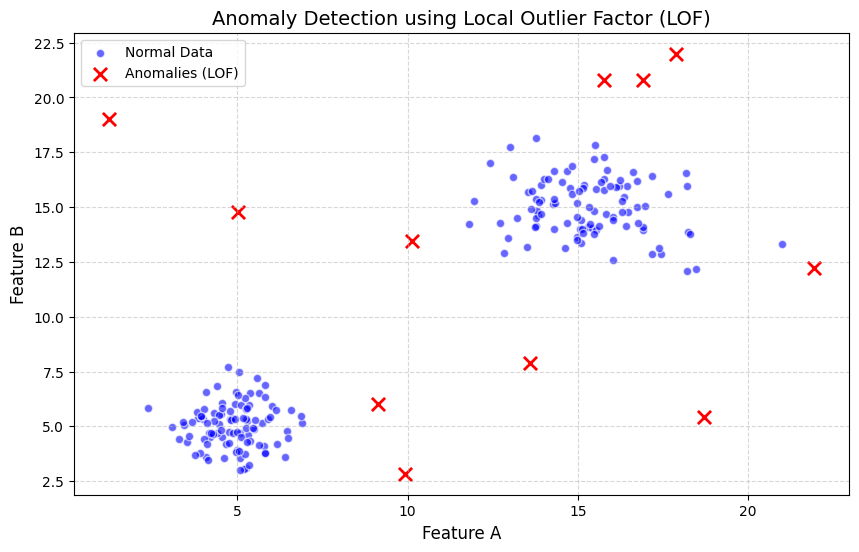

In [4]:
# Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect
# anomalies and visualize them using matplotlib.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)
cluster1 = np.random.normal(loc=5, scale=1, size=(100, 2))
cluster2 = np.random.normal(loc=15, scale=1.5, size=(100, 2))
outliers = np.random.uniform(low=0, high=22, size=(10, 2))
all_data = np.vstack([cluster1, cluster2, outliers])
df = pd.DataFrame(all_data, columns=["Feature_A", "Feature_B"])

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

df["Result"] = lof.fit_predict(df[["Feature_A", "Feature_B"]])

normal_points = df[df["Result"] == 1]
anomaly_points = df[df["Result"] == -1]

plt.figure(figsize=(10, 6))

plt.scatter(
    normal_points["Feature_A"],
    normal_points["Feature_B"],
    color="blue",
    label="Normal Data",
    alpha=0.6,
    edgecolors="w",
)

plt.scatter(
    anomaly_points["Feature_A"],
    anomaly_points["Feature_B"],
    color="red",
    label="Anomalies (LOF)",
    marker="x",
    s=90,
    linewidths=2,
)
plt.title("Anomaly Detection using Local Outlier Factor (LOF)", fontsize=14)
plt.xlabel("Feature A", fontsize=12)
plt.ylabel("Feature B", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Question 10: You are working as a data scientist for a power grid monitoring company.Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage.Explain your real-time data science workflow:
● How would you detect anomalies in this streaming data (Isolation Forest / LOF / DBSCAN)?
● Which time series model would you use for short-term forecasting (ARIMA / SARIMA / SARIMAX)?
● How would you validate and monitor the performance over time?
● How would this solution help business decisions or operations?

Answer: Real-Time Anomaly Detection for power grid monitoting company
- I will use Isolation forest because it will isolate rare spikes or drops quickly with very few tree splits.
- SARIMAX will better suited for time series model because energy usage is cyclical which allows exogenous variables like temprature that will drive sudden shift in power demand.
- Validate model using rolling window and monitor MAPE for forecase accuracy and track error in metrics.
- it will help in grid stability of power demand and fast repairs if sudden error drops.

